# K-Nearest Neighbours (KNN) — CIC-IDS 2018 | Wrapper Method (RFE)

**Dataset:** CIC-IDS 2018 (balanced parquet)  
**Cross-evaluation:** CIC-IDS 2017 (natural distribution)  
**Feature Selection:** Wrapper method — Recursive Feature Elimination (RFE) with Decision Tree proxy  
**Pipeline:** Load data → Group labels → Clean → Encode → Split → Scale → RFE sweep (DT proxy) → Rank features → Evaluate → Cross-dataset (Method 1)

> KNN does not expose `coef_` or `feature_importances_`, so a Decision Tree proxy is used during RFE to rank features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/cic2018_balanced_dataset_standardized.parquet"
raw_data = pd.read_parquet(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,Protocol,Timestamp,Dst Port,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Packets/s,Bwd Packets/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Header Length.1,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6.0,14/02/2018 08:53:42,60556.0,157.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,12738.853516,157.0,0.000000e+00,157.0,157.0,157.0,157.00,0.0,157.0,157.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,12738.853516,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.000000,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,255.0,-1.0,0.0,20.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
1,6.0,14/02/2018 10:38:48,80.0,53993792.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.037041,53993792.0,0.000000e+00,53993792.0,53993792.0,53993792.0,53993792.00,0.0,53993792.0,53993792.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,0.037041,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.000000,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,279.0,-1.0,0.0,20.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
2,6.0,14/02/2018 09:38:17,443.0,61113950.0,16.0,14.0,1578.0,2749.0,538.0,0.0,98.625,178.133987,1116.0,0.0,196.357147,371.917389,70.802162,0.490886,2107377.5,4.100328e+06,10012729.0,19.0,61113950.0,4074263.25,5012311.5,10024262.0,315.0,61102345.0,4700180.5,5125839.0,10024270.0,284.0,0.0,0.0,0.0,0.0,332.0,364.0,0.261806,0.229080,0.0,1116.0,139.580643,280.809509,78853.984375,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,144.233337,98.625,196.357147,332.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,1578.0,14.0,2749.0,8192.0,131.0,11.0,20.0,83368.664062,175935.75,442496.0,11484.0,9992150.0,33221.078125,10012729.0,9924726.0,Benign
3,17.0,14/02/2018 11:19:03,53.0,79651.0,1.0,1.0,35.0,51.0,35.0,35.0,35.000,0.000000,51.0,51.0,51.000000,0.000000,1079.710205,25.109541,79651.0,0.000000e+00,79651.0,79651.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,12.554770,12.554770,35.0,51.0,40.333332,9.237604,85.333336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,60.500000,35.000,51.000000,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,35.0,1.0,51.0,-1.0,-1.0,0.0,8.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
4,17.0,14/02/2018 09:19:31,53.0,12230.0,1.0,1.0,55.0,83.0,55.0,55.0,55.000,0.000000,83.0,83.0,83.000000,0.000000,11283.728516,163.532303,12230.0,0.000000e+00,12230.0,12230.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,81.766151,81.766151,55.0,83.0,64.333336,16.165808,261.333344,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,96.500000,55.000,83.000000,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,55.0,1.0,83.0,-1.0,-1.0,0.0,8.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263642,6.0,23/02/2018 03:17:24,80.0,46.0,2.0

## 1. Load Dataset

Loads the CIC-IDS 2018 balanced dataset from a Parquet file. The raw DataFrame is displayed to confirm dimensions and a sample of the feature space.

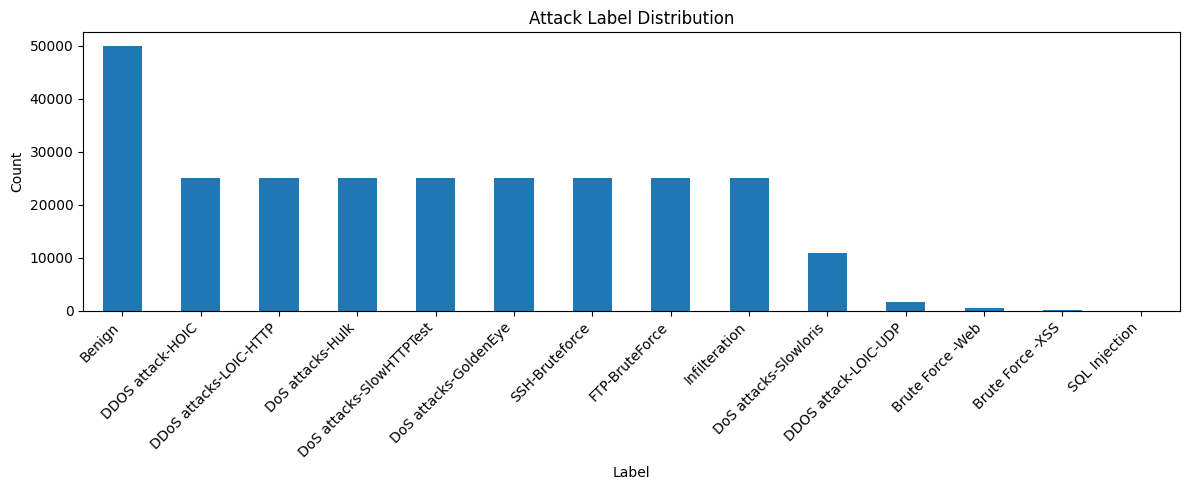

In [2]:
# Label distribution
label_counts = df['Label'].value_counts()

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## 2. Label Distribution

Displays a bar chart of raw attack label counts in the dataset before any grouping or filtering is applied.

In [3]:

# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'Benign': 'BENIGN',

    # DoS / DDoS
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-Slowhttptest': 'DoS',
    
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDoS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',

    # Brute Force
    'FTP-BruteForce': 'BruteForce',
    'SSH-Bruteforce': 'BruteForce',
    
    'Brute Force -Web': 'BruteForce',
    'Brute Force -XSS': 'BruteForce',

    'Infilteration': 'Infiltration',  
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  DoS                      60,990  (25.75%)
  BruteForce               50,841  (21.47%)
  DDoS                     50,000  (21.11%)
  BENIGN                   49,999  (21.11%)
  Infiltration             25,000  (10.56%)


## 3. Group Attack Labels

Maps fine-grained CIC-IDS 2018 attack sub-types (e.g., DoS-Hulk, FTP-BruteForce) into five consolidated categories: BENIGN, DoS, DDoS, BruteForce, and Infiltration. Rows with unmapped labels are dropped.

In [4]:
# Check missing / infinity values
numeric_cols = df.select_dtypes(include=[np.number]).columns
missing = df.isnull().sum()
inf_counts = {col: np.isinf(df[col]).sum() for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("Missing:", missing[missing > 0].to_dict() or "None")
print("Infinity:", inf_counts or "None")


Missing: {'Flow Byts/s': 386}
Infinity: {'Flow Byts/s': np.int64(215), 'Flow Pkts/s': np.int64(601)}


## 4. Check Missing and Infinity Values

Scans all numeric columns for NaN and ±inf values so that data quality issues are identified before any imputation step.

In [5]:
# Handle inf → NaN → median fill
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df_processed.select_dtypes(include=[np.number]).columns:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"Shape: {df_processed.shape}  |  NaN remaining: {df_processed.isnull().sum().sum()}")


Shape: (236830, 81)  |  NaN remaining: 0


/tmp/ipykernel_58502/2395811845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_58502/2395811845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

## 5. Handle Infinity and Missing Values

Replaces ±inf with NaN, then fills each remaining NaN with the column median. This ensures no infinite or missing values are passed to downstream steps.

In [6]:
# Drop metadata columns
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns if any(k in c.lower() for k in keywords)]
df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Shape: {df_processed.shape}")


Shape: (236830, 79)


## 6. Drop Identifier and Metadata Columns

Removes non-feature columns such as Flow ID, IP addresses, ports, and timestamps. These identifiers provide no generalizable signal for intrusion detection models.

In [7]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

with open('label_encoder.pkl1', 'wb') as f:
    pickle.dump(le, f)

print(dict(zip(le.classes_, range(len(le.classes_)))))


{'BENIGN': 0, 'BruteForce': 1, 'DDoS': 2, 'DoS': 3, 'Infiltration': 4}


## 7. Label Encoding

Converts string class labels to integer indices using `LabelEncoder`. The fitted encoder is saved to `label_encoder.pkl1` for later reuse during cross-dataset evaluation.

In [8]:
# Train / test split (stratified 80/20)
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (189464, 78)  |  Test: (47366, 78)


## 8. Train / Test Split

Splits the dataset into 80% training and 20% test sets using stratified sampling to preserve class proportions in both subsets.

In [9]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

with open('scaler.pkl1', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")


Train: (189464, 78)  |  Test: (47366, 78)


## 9. Feature Scaling (StandardScaler)

Standardizes all features to zero mean and unit variance. Required by KNN because it is a distance-based algorithm sensitive to feature magnitude. The scaler is fitted on the training set only and saved for inference.

In [10]:
# RFE — sweep k (proxy: DecisionTree for selection, KNN for evaluation)
from sklearn.feature_selection import RFE, RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

knn_baseline = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_baseline.fit(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, knn_baseline.predict(X_test_scaled))

# KNN has no coef_/feature_importances_, use DecisionTree as proxy for RFE ranking
proxy = DecisionTreeClassifier(max_depth=10, random_state=42)
k_values = [k for k in [10, 20, 30, 40, 50, 60, 70] if k < X_train_scaled.shape[1]]
rfe_results = {}

for k in k_values:
    rfe = RFE(estimator=proxy, n_features_to_select=k, step=140)
    rfe.fit(X_train_scaled, y_train)
    knn_k = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn_k.fit(X_train_scaled.iloc[:, rfe.support_], y_train)
    rfe_results[k] = {'accuracy': accuracy_score(y_test, knn_k.predict(X_test_scaled.iloc[:, rfe.support_])), 'support': rfe.support_}

best_k = max(rfe_results, key=lambda k: rfe_results[k]['accuracy'])
print(f"Baseline: {test_acc*100:.2f}%  |  Best k={best_k}: {rfe_results[best_k]['accuracy']*100:.2f}%")


Baseline: 91.17%  |  Best k=70: 91.11%


## 10. RFE Feature Selection — Sweep k (DT Proxy)

Trains a baseline KNN on all scaled features, then sweeps `k ∈ [10, 20, …, 70]` using a Decision Tree proxy inside RFE (since KNN has no intrinsic feature ranking). For each k the best-k KNN is evaluated, and the k with the highest test accuracy is chosen.

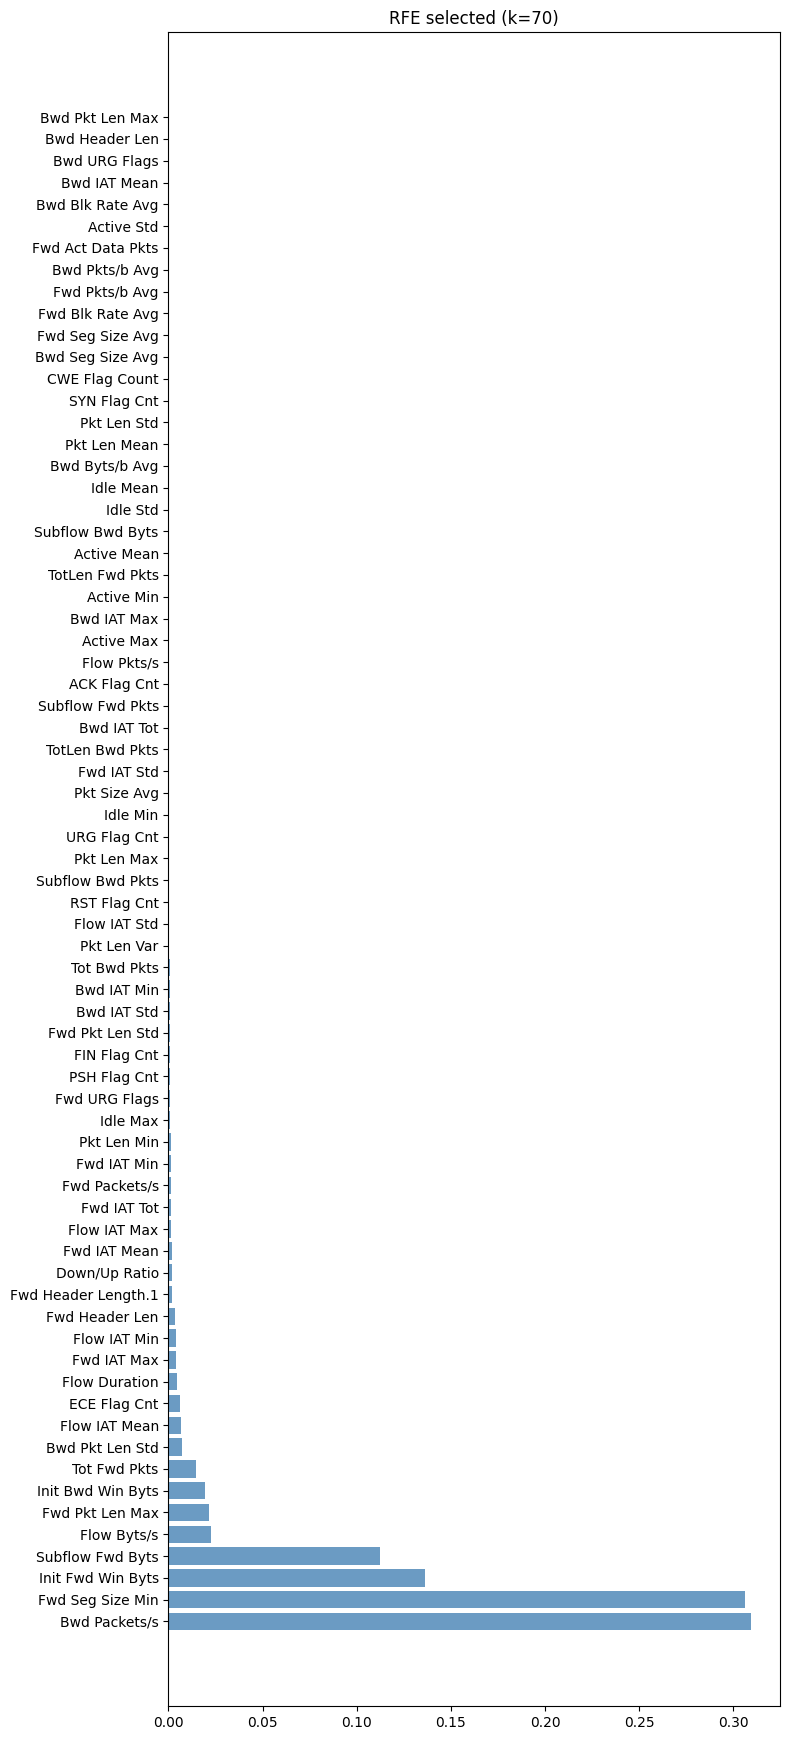

=== RFE k=70 Features (by DT proxy importance) ===
   1. Bwd Packets/s                                 importance=0.3094
   2. Fwd Seg Size Min                              importance=0.3062
   3. Init Fwd Win Byts                             importance=0.1364
   4. Subflow Fwd Byts                              importance=0.1125
   5. Flow Byts/s                                   importance=0.0224
   6. Fwd Pkt Len Max                               importance=0.0215
   7. Init Bwd Win Byts                             importance=0.0196
   8. Tot Fwd Pkts                                  importance=0.0148
   9. Bwd Pkt Len Std                               importance=0.0074
  10. Flow IAT Mean                                 importance=0.0067
  11. ECE Flag Cnt                                  importance=0.0059
  12. Flow Duration                                 importance=0.0044
  13. Fwd IAT Max                                   importance=0.0038
  14. Flow IAT Min                     

In [11]:

# Feature ranking (RFE best_k) — importance via DT proxy
best_rfe = RFE(estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
               n_features_to_select=best_k, step=140)
best_rfe.fit(X_train_scaled, y_train)

rfe_features = X_train_scaled.columns[best_rfe.support_].tolist()
importances = best_rfe.estimator_.feature_importances_
selected_df = pd.DataFrame({'Feature': rfe_features, 'Importance': importances}) \
                .sort_values('Importance', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(4, best_k * 0.25)))
ax.barh(selected_df['Feature'], selected_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title(f'RFE selected (k={best_k})'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Reuse best_rfe for cross-dataset validation (no re-training) ──────────────
import pickle

knn_rfe = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_rfe.fit(X_train_scaled[rfe_features], y_train)

rfe_sorted = pd.Series(best_rfe.estimator_.feature_importances_,
                        index=rfe_features).sort_values(ascending=False)

print(f"=== RFE k={best_k} Features (by DT proxy importance) ===")
for i, (feat, imp) in enumerate(rfe_sorted.items(), 1):
    print(f"  {i:2d}. {feat:<45} importance={imp:.4f}")

with open('knn_rfe20_model.pkl', 'wb') as f: pickle.dump(knn_rfe, f)
with open('rfe20_selected_features.pkl', 'wb') as f: pickle.dump(rfe_features, f)


## 11. RFE Feature Ranking and Final Model

Re-fits RFE with `best_k` to obtain stable feature rankings via the DT proxy's `feature_importances_`. A horizontal bar chart displays the selected features sorted by importance. The final KNN model and feature list are saved to disk.

In [ ]:

# ── Classification report ─────────────────────────────────────────────────────
y_test_pred = knn_rfe.predict(X_test_scaled[rfe_features])
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.7740    0.8207    0.7967     10000
  BruteForce     0.9985    0.9994    0.9990     10168
        DDoS     0.9994    0.9995    0.9995     10000
         DoS     0.9985    0.9984    0.9985     12198
Infiltration     0.5955    0.5226    0.5567      5000

    accuracy                         0.9111     47366
   macro avg     0.8732    0.8681    0.8700     47366
weighted avg     0.9088    0.9111    0.9095     47366



## 12. Classification Report — RFE Model

Prints per-class precision, recall, F1-score, and support for KNN trained on the `best_k` RFE-selected features, evaluated on the held-out test set.

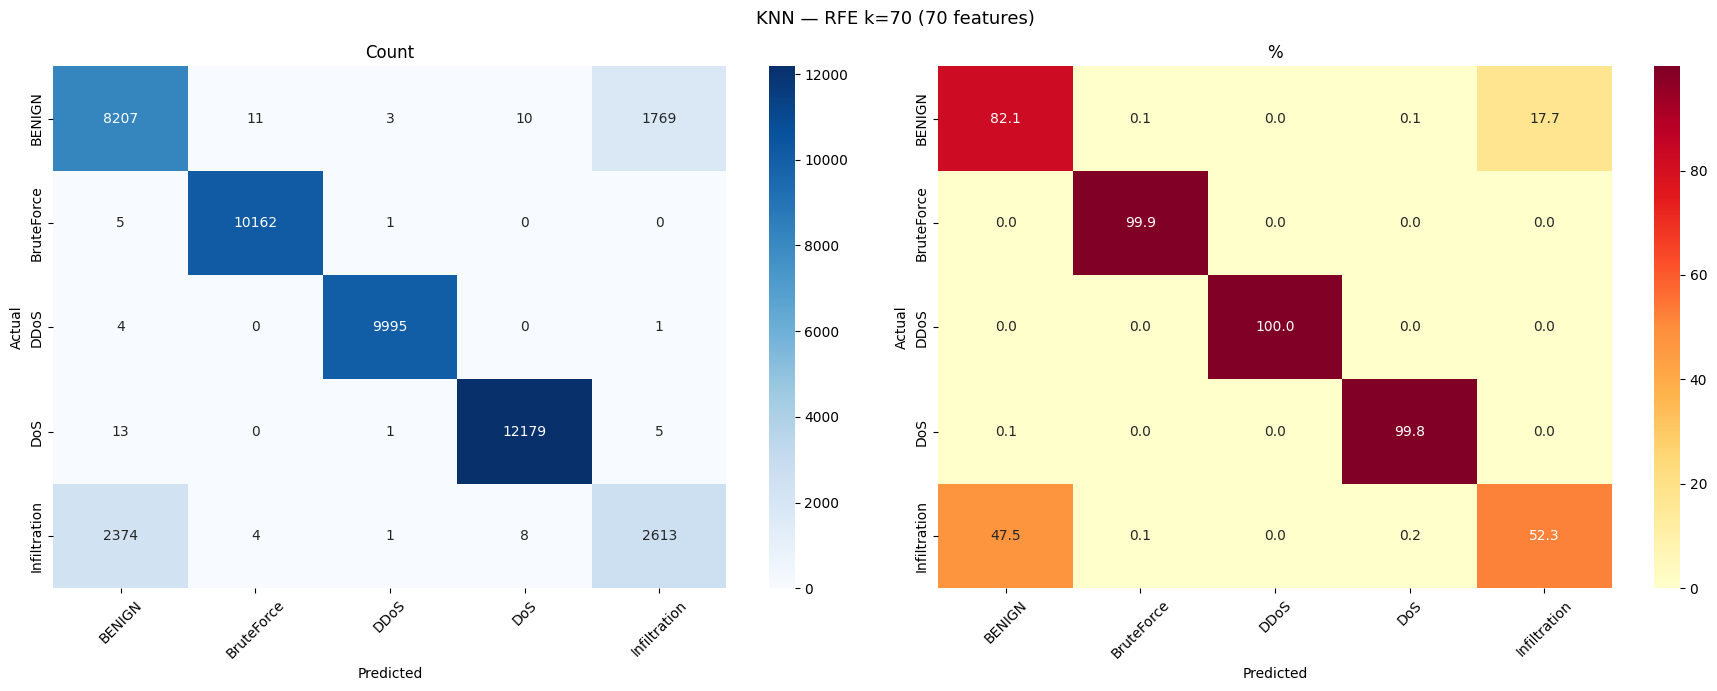

In [13]:

# Confusion matrix — RFE model
cm = confusion_matrix(y_test, knn_rfe.predict(X_test_scaled[rfe_features]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Count'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual'); ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('%'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual'); ax2.tick_params(axis='x', rotation=45)

plt.suptitle(f'KNN — RFE k={best_k} ({best_k} features)', fontsize=13)
plt.tight_layout(); plt.show()


## 13. Confusion Matrix — RFE Model

Side-by-side heatmaps showing the absolute count (left) and row-normalised percentage (right) for each true vs. predicted class pair.

---

## Cross-Dataset Evaluation (CIC-IDS 2017)

Evaluates the 2018-trained model against CIC-IDS 2017 data to measure generalisation across datasets.

- **Method 1 — Cross-test:** apply the 2018-trained KNN to CIC-2017 using only features shared between both datasets; a sub-scaler is re-fitted on the training shared features to avoid data leakage

In [14]:
# Load CIC-2017 cross-test dataset (natural distribution)
CIC17_PATH = "../../../../dataset/cicids2017_sample_1M_natural_standardized.csv"
df17_raw = pd.read_csv(CIC17_PATH)
print(f"Shape: {df17_raw.shape}")
print(df17_raw['Label'].value_counts())


Shape: (864031, 79)
Label
BENIGN                        640639
DoS Hulk                      130108
DDoS                           72103
DoS GoldenEye                   5711
FTP-Patator                     4456
SSH-Patator                     3400
DoS slowloris                   3275
DoS Slowhttptest                3058
Web Attack � Brute Force         868
Web Attack � XSS                 361
Infiltration                      36
Heartbleed                        10
Web Attack � Sql Injection         6
Name: count, dtype: int64


## 14. Load CIC-IDS 2017

Loads the CIC-IDS 2017 dataset (1 M rows, natural class distribution) from CSV. The raw label distribution is printed before any grouping.

In [15]:
attack_group_mapping_17 = {
    # # BENIGN
    'BENIGN': 'BENIGN',

    # DoS / DDoS
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS Slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    
    'DDoS': 'DDoS',

    # Brute Force
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    
    'Web Attack � XSS': 'BruteForce',
    'Web Attack � Brute Force': 'BruteForce',

    'Heartbleed': 'Infiltration',
    'Infiltration': 'Infiltration',
}

df17 = df17_raw.copy()
df17['Label'] = df17['Label'].map(attack_group_mapping_17)
df17.dropna(subset=['Label'], inplace=True)

for g, cnt in df17['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df17)*100:.2f}%)")


  BENIGN                  640,639  (74.43%)
  DoS                     138,877  (16.13%)
  DDoS                     72,103  (8.38%)
  BruteForce                9,085  (1.06%)
  Infiltration                 46  (0.01%)


## 15. Group CIC-IDS 2017 Attack Labels

Applies the same label grouping strategy used for CIC-IDS 2018 so that both datasets share a common set of class names for cross-dataset comparison.

In [16]:
# Preprocess 2017 (same pipeline as 2018)
df17_proc = df17.copy()
df17_proc.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df17_proc.select_dtypes(include=[np.number]).columns:
    if df17_proc[col].isnull().sum() > 0:
        df17_proc[col].fillna(df17_proc[col].median(), inplace=True)

keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop_17 = [c for c in df17_proc.columns if any(k in c.lower() for k in keywords)]
df17_proc.drop(columns=cols_to_drop_17, inplace=True, errors='ignore')
print(f"Shape: {df17_proc.shape}  |  NaN: {df17_proc.isnull().sum().sum()}")


/tmp/ipykernel_58502/2689547596.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df17_proc[col].fillna(df17_proc[col].median(), inplace=True)
/tmp/ipykernel_58502/2689547596.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Shape: (860750, 78)  |  NaN: 0


## 16. Preprocess CIC-IDS 2017

Applies the same cleaning pipeline to the 2017 data: replace ±inf → NaN, fill with median, and drop identifier columns. This ensures feature compatibility with the 2018-trained model.

In [ ]:

# Method 1: Cross-test — shared features only (no zero-fill)
shared_features = [f for f in rfe_features if f in df17_proc.columns]
missing_in_17 = [f for f in rfe_features if f not in df17_proc.columns]

print(f"RFE k={best_k}: {len(rfe_features)} features  |  Shared with CIC-2017: {len(shared_features)}  |  Missing: {len(missing_in_17)}")
if missing_in_17:
    print(f"  Missing features: {missing_in_17}")

X17 = df17_proc[shared_features]
y17_labels = df17_proc['Label']

known_classes = set(le.classes_)
mask_known = y17_labels.isin(known_classes)
X17 = X17[mask_known]
y17_labels = y17_labels[mask_known]
y17 = le.transform(y17_labels)

# Scale using the shared features (refit scaler on raw training shared features)
scaler_sub = StandardScaler()
X_train_sub_s = scaler_sub.fit_transform(X_train[shared_features])
X_test_sub_s  = scaler_sub.transform(X_test[shared_features])
X17_sub_s     = scaler_sub.transform(X17)

KNN_Shared = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
KNN_Shared.fit(X_train_sub_s, y_train)
y17_pred = KNN_Shared.predict(X17_sub_s)
acc_src  = accuracy_score(y_test, KNN_Shared.predict(X_test_sub_s))

acc17 = accuracy_score(y17, y17_pred)
print(f"\nCIC-2018 (source): {acc_src*100:.2f}%")
print(f"CIC-2017 (target): {acc17*100:.2f}%  |  Drop: {(acc_src-acc17)*100:.2f}%")
print()
present_indices = sorted(set(y17))
print(classification_report(y17, y17_pred, labels=present_indices,
                            target_names=le.inverse_transform(present_indices),
                            digits=4, zero_division=0))


RFE k=70: 70 features  |  Shared with CIC-2017: 70  |  Missing: 0

CIC-2018 (source): 91.11%
CIC-2017 (target): 57.32%  |  Drop: 33.80%

              precision    recall  f1-score   support

      BENIGN     0.9154    0.7133    0.8018    640639
  BruteForce     0.0271    0.4831    0.0513      9085
        DDoS     0.4332    0.0117    0.0228     72103
         DoS     0.4771    0.2240    0.3049    138877
Infiltration     0.0000    0.1304    0.0001        46

    accuracy                         0.5732    860750
   macro avg     0.3706    0.3125    0.2362    860750
weighted avg     0.7949    0.5732    0.6484    860750



: 

## 17. Method 1 — Cross-Test (shared RFE features, scaled)

Evaluates the 2018-trained KNN directly on CIC-IDS 2017. A sub-scaler is re-fitted on the training shared features to prevent data leakage. Accuracy on CIC-2018 and CIC-2017 is compared to quantify the performance drop due to domain shift.